In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load preprocessed splits
# Original scaled training data (not SMOTE)
X_train_scaled = pd.read_csv("Data/X_train_scaled.csv")
y_train = pd.read_csv("Data/y_train.csv").squeeze()

X_val_scaled = pd.read_csv("Data/X_val_scaled.csv")
y_val = pd.read_csv("Data/y_val.csv").squeeze()

X_test_scaled = pd.read_csv("Data/X_test_scaled.csv")
y_test = pd.read_csv("Data/y_test.csv").squeeze()

imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

print("Loaded preprocessed splits.")
print(f"  Train:      {X_train_scaled.shape[0]:,} samples")
print(f"  Validation: {X_val_scaled.shape[0]:,} samples")
print(f"  Test:       {X_test_scaled.shape[0]:,} samples")
print(f"  Imbalance ratio (for scale_pos_weight): {imbalance_ratio:.2f}")

Loaded preprocessed splits.
  Train:      160,846 samples
  Validation: 34,467 samples
  Test:       34,468 samples
  Imbalance ratio (for scale_pos_weight): 8.69


In [3]:
# XGBoost: Training & Tuning
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
}

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio,
    n_jobs=-1
)

xgb_grid = GridSearchCV(
    xgb_base, xgb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)

print("Starting XGBoost grid search...")
xgb_grid.fit(X_train_scaled, y_train)
print(f"\nBest params: {xgb_grid.best_params_}")
print(f"Best CV AUC-ROC: {xgb_grid.best_score_:.4f}")

Starting XGBoost grid search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV AUC-ROC: 0.8374


In [ ]:
# Validation Set Evaluation

xgb_best = xgb_grid.best_estimator_

xgb_val_preds = xgb_best.predict(X_val_scaled)
xgb_val_probs = xgb_best.predict_proba(X_val_scaled)[:, 1]

print("XGBoost — Validation Set Results\n")
print(classification_report(y_val, xgb_val_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, xgb_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, xgb_val_preds):.4f}")
print(f"Precision: {precision_score(y_val, xgb_val_preds):.4f}")
print(f"Recall:    {recall_score(y_val, xgb_val_preds):.4f}")

XGBoost — Validation Set Results

               precision    recall  f1-score   support

        No HD       0.97      0.72      0.83     30910
Heart Disease       0.25      0.80      0.38      3557

     accuracy                           0.73     34467
    macro avg       0.61      0.76      0.60     34467
 weighted avg       0.89      0.73      0.78     34467

AUC-ROC:   0.8386
F1:        0.3776
Precision: 0.2471
Recall:    0.8010


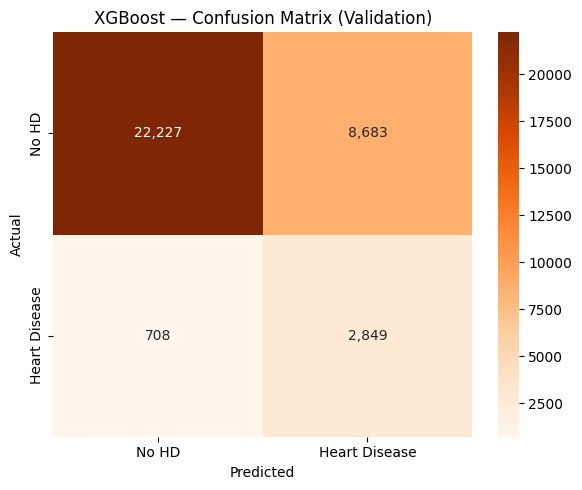

In [5]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_xgb = confusion_matrix(y_val, xgb_val_preds)
sns.heatmap(cm_xgb, annot=True, fmt=',', cmap='Oranges', ax=ax,
            xticklabels=['No HD', 'Heart Disease'],
            yticklabels=['No HD', 'Heart Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('XGBoost — Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()

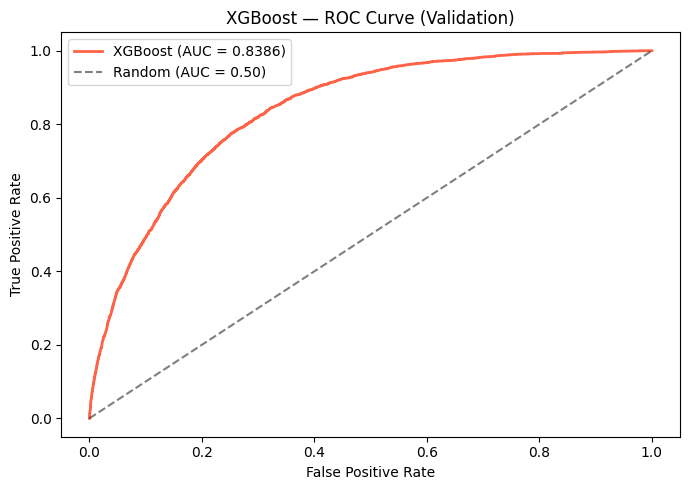

In [6]:
# ROC curve
xgb_fpr, xgb_tpr, _ = roc_curve(y_val, xgb_val_probs)
xgb_auc = roc_auc_score(y_val, xgb_val_probs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xgb_fpr, xgb_tpr, color='tomato', lw=2, label=f'XGBoost (AUC = {xgb_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('XGBoost — ROC Curve (Validation)')
ax.legend()
plt.tight_layout()
plt.show()

XGBoost: Threshold Optimization
  Default threshold: 0.50
  Optimal threshold (F2): 0.5354
  Precision at optimal: 0.2614
  Recall at optimal:    0.7751
  F2 at optimal:       0.5564


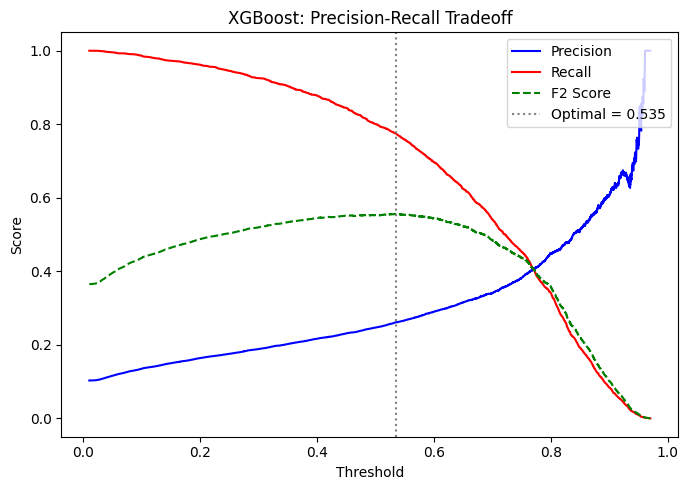

In [9]:
# Threshold Optimization
def find_optimal_threshold(y_true, y_probs, model_name, beta=2.0):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    fbeta_scores = ((1 + beta**2) * precisions * recalls) / (beta**2 * precisions + recalls + 1e-8)
    best_idx = np.argmax(fbeta_scores)
    best_threshold = thresholds[best_idx]

    print(f"{model_name}: Threshold Optimization")
    print(f"  Default threshold: 0.50")
    print(f"  Optimal threshold (F{beta:.0f}): {best_threshold:.4f}")
    print(f"  Precision at optimal: {precisions[best_idx]:.4f}")
    print(f"  Recall at optimal:    {recalls[best_idx]:.4f}")
    print(f"  F{beta:.0f} at optimal:       {fbeta_scores[best_idx]:.4f}")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(thresholds, precisions[:-1], 'b-', label='Precision')
    ax.plot(thresholds, recalls[:-1], 'r-', label='Recall')
    ax.plot(thresholds, fbeta_scores[:-1], 'g--', label=f'F{beta:.0f} Score')
    ax.axvline(x=best_threshold, color='gray', linestyle=':', label=f'Optimal = {best_threshold:.3f}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name}: Precision-Recall Tradeoff')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return best_threshold

xgb_threshold = find_optimal_threshold(y_val, xgb_val_probs, "XGBoost")

In [10]:
# Re-evaluate at optimal threshold
xgb_opt_preds = (xgb_val_probs >= xgb_threshold).astype(int)

print(f"\n=== XGBoost — Results at threshold {xgb_threshold:.4f} ===\n")
print(classification_report(y_val, xgb_opt_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, xgb_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, xgb_opt_preds):.4f}")
print(f"Precision: {precision_score(y_val, xgb_opt_preds):.4f}")
print(f"Recall:    {recall_score(y_val, xgb_opt_preds):.4f}")


=== XGBoost — Results at threshold 0.5354 ===

               precision    recall  f1-score   support

        No HD       0.97      0.75      0.84     30910
Heart Disease       0.26      0.78      0.39      3557

     accuracy                           0.75     34467
    macro avg       0.61      0.76      0.62     34467
 weighted avg       0.89      0.75      0.80     34467

AUC-ROC:   0.8386
F1:        0.3910
Precision: 0.2614
Recall:    0.7751


XGBoost: SHAP Summary


/var/folders/dq/d73590ld0qdgbx2nj4pms7hw0000gn/T/ipykernel_84332/2277982716.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(xgb_shap_values, X_val_scaled.iloc[xgb_sample_idx], show=True)


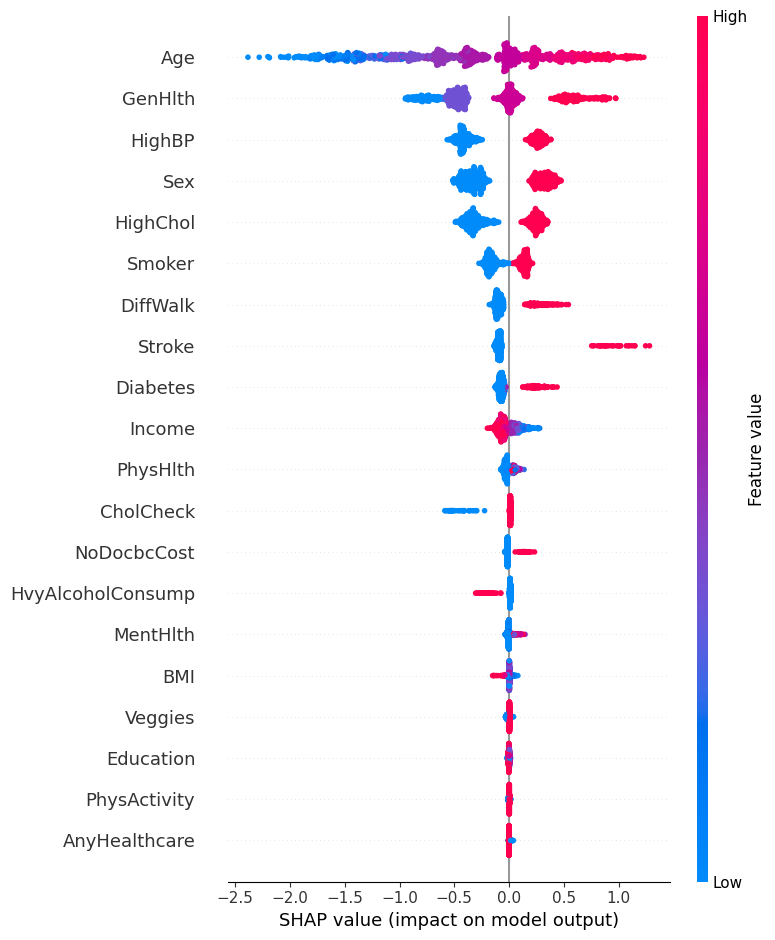

XGBoost: SHAP Feature Importance


/var/folders/dq/d73590ld0qdgbx2nj4pms7hw0000gn/T/ipykernel_84332/2277982716.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(xgb_shap_values, X_val_scaled.iloc[xgb_sample_idx], plot_type="bar", show=True)


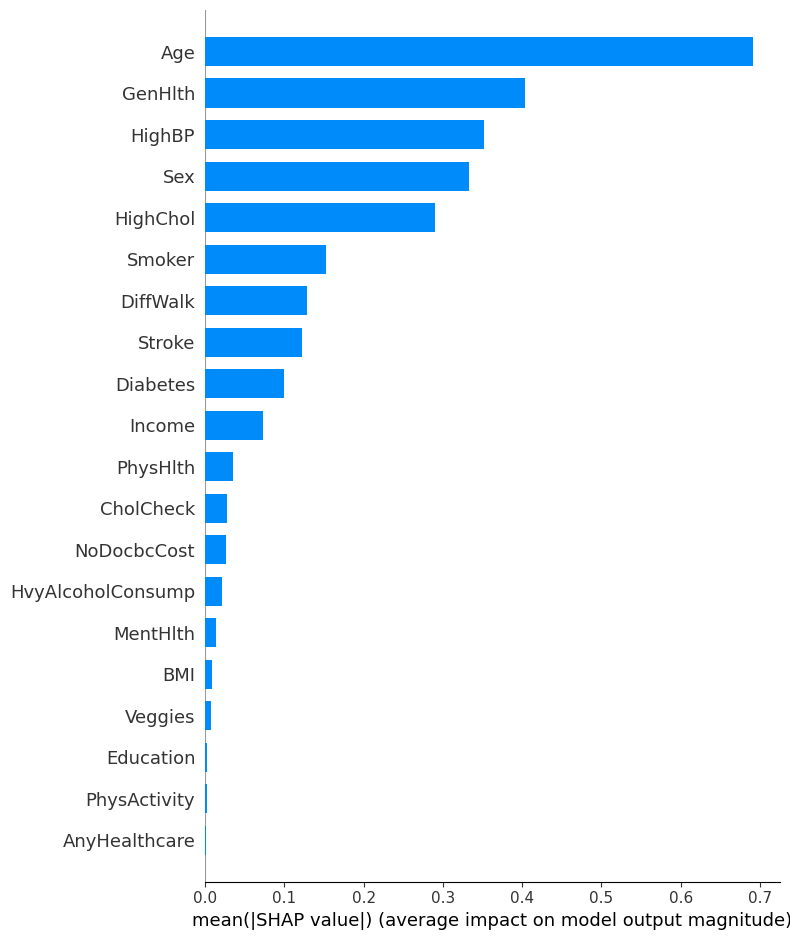

In [11]:
# SHAP Analysis
import shap

xgb_sample_idx = np.random.choice(len(X_val_scaled), size=min(1000, len(X_val_scaled)), replace=False)
xgb_explainer = shap.TreeExplainer(xgb_best)
xgb_shap_values = xgb_explainer.shap_values(X_val_scaled.iloc[xgb_sample_idx])

print("XGBoost: SHAP Summary")
shap.summary_plot(xgb_shap_values, X_val_scaled.iloc[xgb_sample_idx], show=True)

# %%
print("XGBoost: SHAP Feature Importance")
shap.summary_plot(xgb_shap_values, X_val_scaled.iloc[xgb_sample_idx], plot_type="bar", show=True)

In [13]:
# LIME Analysis
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=X_train_scaled.columns.tolist(),
    class_names=['No HD', 'Heart Disease'],
    mode='classification'
)

# Find interesting cases
xgb_opt_preds_arr = (xgb_val_probs >= xgb_threshold).astype(int)
tp_idx = np.where((xgb_opt_preds_arr == 1) & (y_val.values == 1))[0]
fn_idx = np.where((xgb_opt_preds_arr == 0) & (y_val.values == 1))[0]
print(f"True positives:  {len(tp_idx)}")
print(f"False negatives: {len(fn_idx)}")


True positives:  2757
False negatives: 800


LIME: True Positive
Actual: Heart Disease | Predicted prob: 0.7155


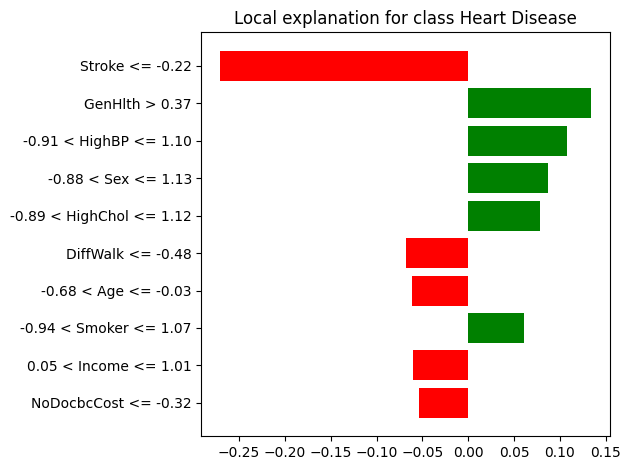

In [14]:
# LIME for a true positive
if len(tp_idx) > 0:
    case_tp = tp_idx[0]
    exp_tp = lime_explainer.explain_instance(
        X_val_scaled.iloc[case_tp].values,
        xgb_best.predict_proba, num_features=10
    )
    print("LIME: True Positive")
    print(f"Actual: Heart Disease | Predicted prob: {xgb_val_probs[case_tp]:.4f}")
    exp_tp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

LIME: False Negative
Actual: Heart Disease | Predicted prob: 0.5236


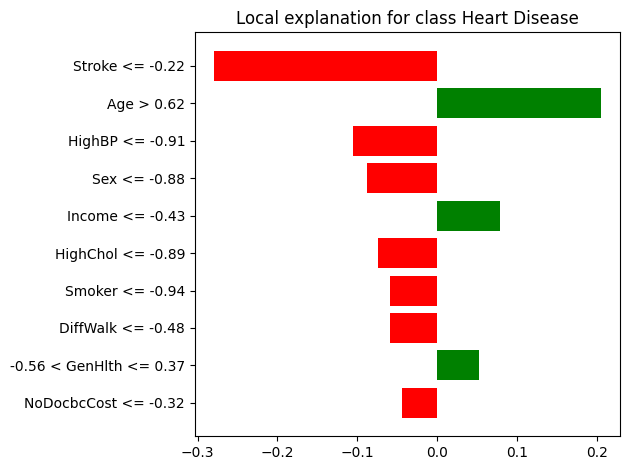

In [15]:
# LIME for a false negative
if len(fn_idx) > 0:
    case_fn = fn_idx[0]
    exp_fn = lime_explainer.explain_instance(
        X_val_scaled.iloc[case_fn].values,
        xgb_best.predict_proba, num_features=10
    )
    print("LIME: False Negative")
    print(f"Actual: Heart Disease | Predicted prob: {xgb_val_probs[case_fn]:.4f}")
    exp_fn.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

In [17]:
# Test Set Evulation
xgb_test_probs = xgb_best.predict_proba(X_test_scaled)[:, 1]
xgb_test_preds = (xgb_test_probs >= xgb_threshold).astype(int)

print(f"XGBoost: Test Set (threshold = {xgb_threshold:.4f})\n")
print(classification_report(y_test, xgb_test_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_test, xgb_test_probs):.4f}")
print(f"F1:        {f1_score(y_test, xgb_test_preds):.4f}")
print(f"Precision: {precision_score(y_test, xgb_test_preds):.4f}")
print(f"Recall:    {recall_score(y_test, xgb_test_preds):.4f}")

XGBoost: Test Set (threshold = 0.5354)

               precision    recall  f1-score   support

        No HD       0.97      0.75      0.84     30910
Heart Disease       0.26      0.78      0.39      3558

     accuracy                           0.75     34468
    macro avg       0.61      0.76      0.62     34468
 weighted avg       0.89      0.75      0.80     34468

AUC-ROC:   0.8407
F1:        0.3913
Precision: 0.2615
Recall:    0.7774


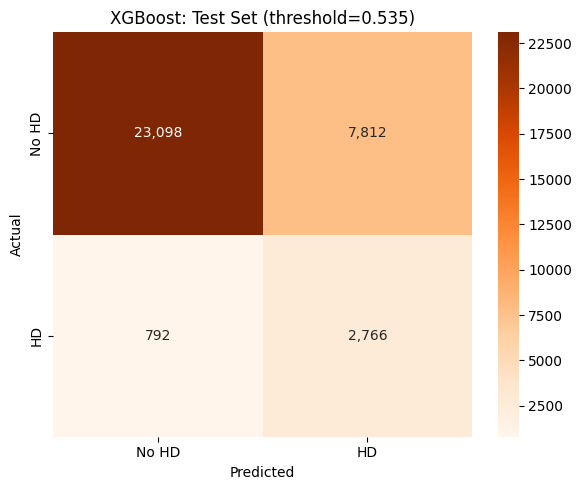

In [18]:
# Test set confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, xgb_test_preds), annot=True, fmt=',', cmap='Oranges',
            ax=ax, xticklabels=['No HD', 'HD'], yticklabels=['No HD', 'HD'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'XGBoost: Test Set (threshold={xgb_threshold:.3f})')
plt.tight_layout()
plt.show()

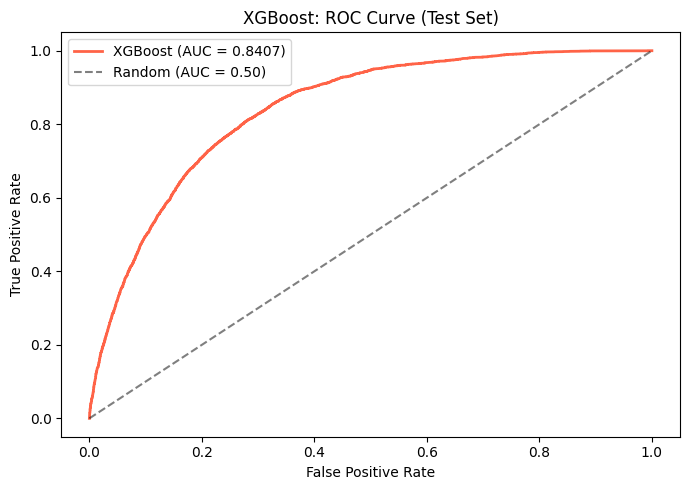

In [19]:
# Test set ROC curve
xgb_test_fpr, xgb_test_tpr, _ = roc_curve(y_test, xgb_test_probs)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xgb_test_fpr, xgb_test_tpr, color='tomato', lw=2,
        label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_test_probs):.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('XGBoost: ROC Curve (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()